<a href="https://colab.research.google.com/github/khushivats0201/CODSOFT/blob/main/CUSTOMER_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [12]:
from google.colab import files

print(" Please upload  Churn_Modelling.csv  when the picker opens...")
uploaded = files.upload()
print("\n✅ Uploaded:", list(uploaded.keys()))

 Please upload  Churn_Modelling.csv  when the picker opens...


Saving Churn_Modelling.csv to Churn_Modelling.csv

✅ Uploaded: ['Churn_Modelling.csv']


In [13]:
df = pd.read_csv('Churn_Modelling.csv')

print("Shape :", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types & null check:")
print(df.info())

print("\nBasic statistics:")
display(df.describe())

print(f"\nChurn distribution:\n{df['Exited'].value_counts()}")
print(f"\nChurn rate : {df['Exited'].mean()*100:.2f}%")

Shape : (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Data types & null check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Basic statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate : 20.37%


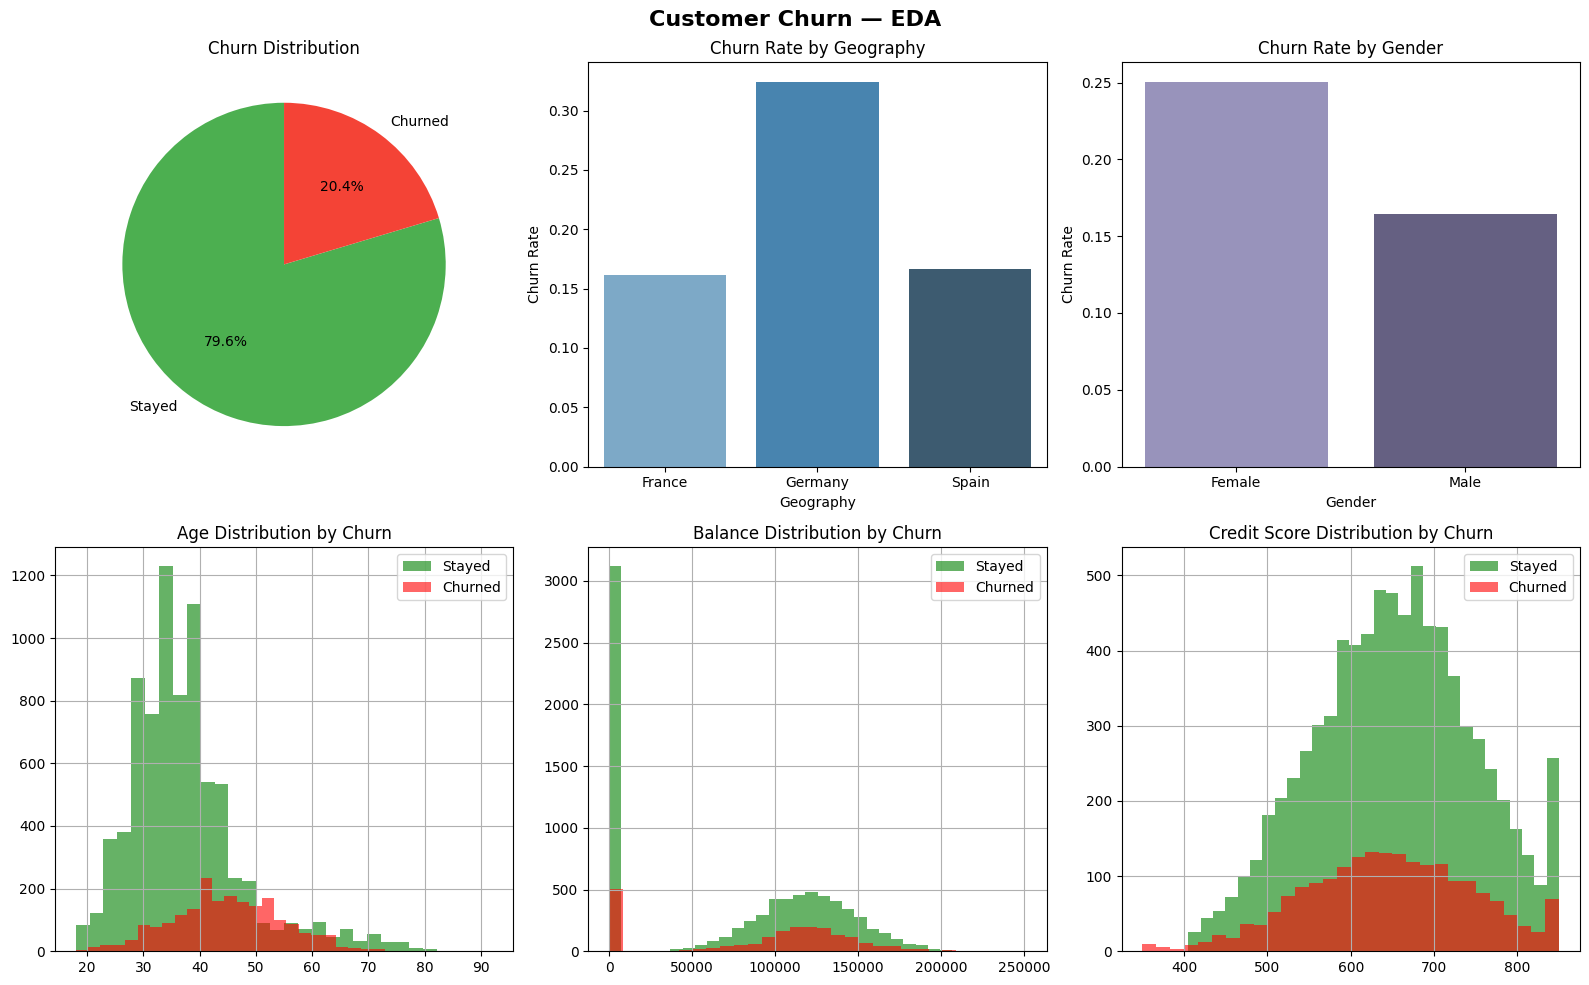

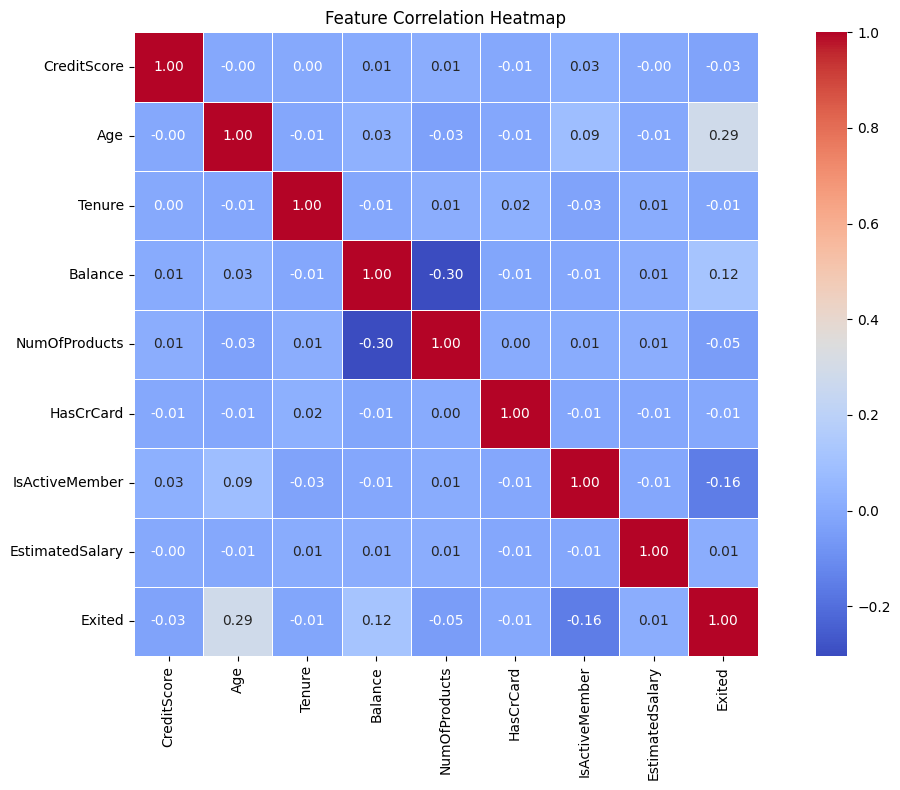

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn — EDA', fontsize=16, fontweight='bold')

# 4-a  Churn pie chart
axes[0, 0].pie(df['Exited'].value_counts(), labels=['Stayed', 'Churned'],
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[0, 0].set_title('Churn Distribution')

# 4-b  Churn by Geography
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(data=geo_churn, x='Geography', y='Exited', ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title('Churn Rate by Geography')
axes[0, 1].set_ylabel('Churn Rate')

# 4-c  Churn by Gender
gen_churn = df.groupby('Gender')['Exited'].mean().reset_index()
sns.barplot(data=gen_churn, x='Gender', y='Exited', ax=axes[0, 2], palette='Purples_d')
axes[0, 2].set_title('Churn Rate by Gender')
axes[0, 2].set_ylabel('Churn Rate')

# 4-d  Age distribution by churn
df[df['Exited'] == 0]['Age'].hist(bins=30, ax=axes[1, 0], alpha=0.6,
                                   color='green', label='Stayed')
df[df['Exited'] == 1]['Age'].hist(bins=30, ax=axes[1, 0], alpha=0.6,
                                   color='red', label='Churned')
axes[1, 0].set_title('Age Distribution by Churn')
axes[1, 0].legend()

# 4-e  Balance distribution by churn
df[df['Exited'] == 0]['Balance'].hist(bins=30, ax=axes[1, 1], alpha=0.6,
                                       color='green', label='Stayed')
df[df['Exited'] == 1]['Balance'].hist(bins=30, ax=axes[1, 1], alpha=0.6,
                                       color='red', label='Churned')
axes[1, 1].set_title('Balance Distribution by Churn')
axes[1, 1].legend()

# 4-f  Credit Score by churn
df[df['Exited'] == 0]['CreditScore'].hist(bins=30, ax=axes[1, 2], alpha=0.6,
                                           color='green', label='Stayed')
df[df['Exited'] == 1]['CreditScore'].hist(bins=30, ax=axes[1, 2], alpha=0.6,
                                           color='red', label='Churned')
axes[1, 2].set_title('Credit Score Distribution by Churn')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=np.number).drop(
    columns=['RowNumber', 'CustomerId'], errors='ignore'
)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [15]:
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode Geography and Gender
le_geo = LabelEncoder()
le_gen = LabelEncoder()
df_model['Geography'] = le_geo.fit_transform(df_model['Geography'])
df_model['Gender']    = le_gen.fit_transform(df_model['Gender'])

# --- Extra engineered features (boosts accuracy) ---
df_model['BalanceSalaryRatio']   = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)
df_model['CreditScorePerAge']    = df_model['CreditScore'] / df_model['Age']
df_model['ProductsPerTenure']    = df_model['NumOfProducts'] / (df_model['Tenure'] + 1)
df_model['IsZeroBalance']        = (df_model['Balance'] == 0).astype(int)
df_model['AgeGroup']             = pd.cut(df_model['Age'],
                                           bins=[0, 30, 40, 50, 60, 100],
                                           labels=[0, 1, 2, 3, 4]).astype(int)

# Split features / target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print("Feature columns:", X.columns.tolist())
print("Feature matrix shape:", X.shape)

# Train / Test split  (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (needed for Logistic Regression)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")



Feature columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'CreditScorePerAge', 'ProductsPerTenure', 'IsZeroBalance', 'AgeGroup']
Feature matrix shape: (10000, 15)

✅ Train : 8,000  |  Test : 2,000


In [16]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, max_depth=10,
                                                      random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                          max_depth=5, random_state=42),
    'XGBoost':                XGBClassifier(n_estimators=200, learning_rate=0.05,
                                             max_depth=6, subsample=0.8,
                                             eval_metric='logloss', random_state=42)
}

# Use scaled data for LR, raw for tree models
X_tr = {'Logistic Regression': X_train_sc,
        'Random Forest':       X_train.values,
        'Gradient Boosting':   X_train.values,
        'XGBoost':             X_train.values}

X_te = {'Logistic Regression': X_test_sc,
        'Random Forest':       X_test.values,
        'Gradient Boosting':   X_test.values,
        'XGBoost':             X_test.values}

results = {}
print(f"\n{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print('─' * 47)

for name, model in models.items():
    model.fit(X_tr[name], y_train)
    preds    = model.predict(X_te[name])
    proba    = model.predict_proba(X_te[name])[:, 1]
    acc      = accuracy_score(y_test, preds)
    auc      = roc_auc_score(y_test, proba)
    results[name] = {'model': model, 'acc': acc, 'auc': auc,
                     'preds': preds, 'proba': proba}
    print(f"  {name:<23} {acc:>10.4f} {auc:>10.4f}")

best_name  = max(results, key=lambda k: results[k]['auc'])
best       = results[best_name]
print(f"\n🏆 Best model : {best_name}  (AUC = {best['auc']:.4f})")



Model                       Accuracy    ROC-AUC
───────────────────────────────────────────────
  Logistic Regression         0.8160     0.7783
  Random Forest               0.8605     0.8547
  Gradient Boosting           0.8560     0.8520
  XGBoost                     0.8630     0.8556

🏆 Best model : XGBoost  (AUC = 0.8556)



  CLASSIFICATION REPORT  —  XGBoost
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



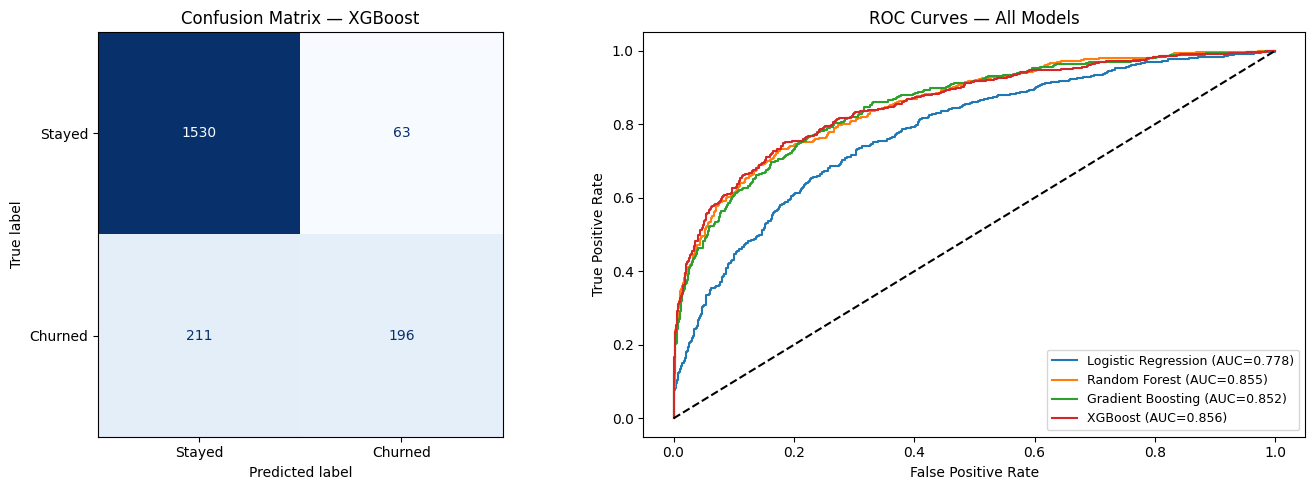

In [17]:
print(f"\n{'='*60}")
print(f"  CLASSIFICATION REPORT  —  {best_name}")
print(f"{'='*60}")
print(classification_report(y_test, best['preds'],
                             target_names=['Stayed', 'Churned']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best['preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')

# ROC Curves for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


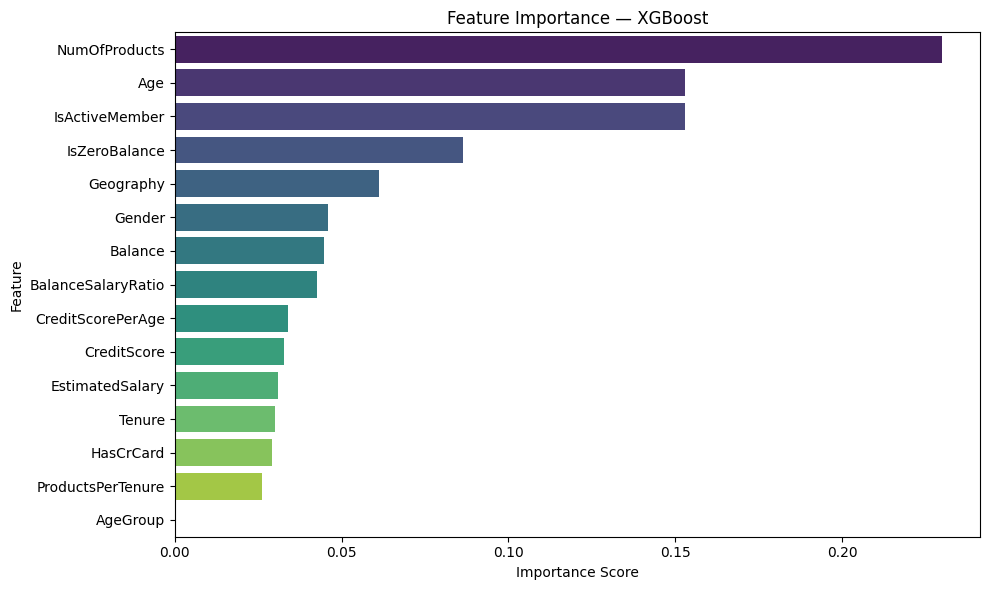


Top 5 most important features:
       Feature  Importance
 NumOfProducts    0.229846
           Age    0.153075
IsActiveMember    0.152882
 IsZeroBalance    0.086295
     Geography    0.061105


In [18]:
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
plot_model_name = best_name if best_name in tree_models else 'XGBoost'
feat_model = results[plot_model_name]['model']

importances = feat_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Feature Importance — {plot_model_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_df.head(5).to_string(index=False))


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_model_obj = results[best_name]['model']
X_cv = X_train_sc if best_name == 'Logistic Regression' else X_train.values

cv_scores = cross_val_score(best_model_obj, X_cv, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n5-Fold Cross-Validation AUC — {best_name}")
print(f"  Scores : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")



5-Fold Cross-Validation AUC — XGBoost
  Scores : [np.float64(0.8562), np.float64(0.8711), np.float64(0.8716), np.float64(0.8408), np.float64(0.8467)]
  Mean   : 0.8573  ±  0.0125


In [20]:
def predict_churn(credit_score, geography, gender, age, tenure,
                  balance, num_products, has_cc, is_active, salary):
    """
    geography : 'France' | 'Spain' | 'Germany'
    gender    : 'Male'   | 'Female'
    """
    geo_enc = le_geo.transform([geography])[0]
    gen_enc = le_gen.transform([gender])[0]

    row = pd.DataFrame([{
        'CreditScore':      credit_score,
        'Geography':        geo_enc,
        'Gender':           gen_enc,
        'Age':              age,
        'Tenure':           tenure,
        'Balance':          balance,
        'NumOfProducts':    num_products,
        'HasCrCard':        has_cc,
        'IsActiveMember':   is_active,
        'EstimatedSalary':  salary,
        'BalanceSalaryRatio':  balance / (salary + 1),
        'CreditScorePerAge':   credit_score / age,
        'ProductsPerTenure':   num_products / (tenure + 1),
        'IsZeroBalance':       int(balance == 0),
        'AgeGroup':            int(pd.cut([age], bins=[0,30,40,50,60,100],
                                          labels=[0,1,2,3,4])[0])
    }])

    X_row = row[X.columns]  # keep column order
    if best_name == 'Logistic Regression':
        X_row = scaler.transform(X_row)
    else:
        X_row = X_row.values

    prob  = best_model_obj.predict_proba(X_row)[0][1]
    label = 'CHURNED 🔴' if prob >= 0.5 else 'STAYED 🟢'
    print(f"\n  Churn Probability : {prob*100:.2f}%")
    print(f"  Prediction        : {label}")
    return prob

# ── Example customer ──
predict_churn(
    credit_score = 600,
    geography    = 'Germany',
    gender       = 'Female',
    age          = 45,
    tenure       = 3,
    balance      = 120000,
    num_products = 1,
    has_cc       = 1,
    is_active    = 0,
    salary       = 80000
)


  Churn Probability : 68.67%
  Prediction        : CHURNED 🔴


np.float32(0.6866606)

In [21]:
import joblib

# Save model + scaler + encoders
joblib.dump(best_model_obj, 'churn_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(le_geo,         'le_geography.pkl')
joblib.dump(le_gen,         'le_gender.pkl')

# Save predictions CSV
pred_df = X_test.copy()
pred_df['Actual_Churn']    = y_test.values
pred_df['Predicted_Churn'] = best['preds']
pred_df['Churn_Probability'] = best['proba'].round(4)
pred_df.to_csv('churn_predictions.csv', index=False)

# Download files
from google.colab import files
files.download('churn_predictions.csv')
files.download('churn_model.pkl')

print("✅ Model and predictions saved & downloaded!")
print(f"\n🎯 Final Test Accuracy : {best['acc']*100:.2f}%")
print(f"🎯 Final Test AUC      : {best['auc']:.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model and predictions saved & downloaded!

🎯 Final Test Accuracy : 86.30%
🎯 Final Test AUC      : 0.8556
